# Notebook 8 — H4: Domain vs Variable Level Features

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

**Hypothesis:** Domain-level feature engineering (7 features) produces superior clustering compared to variable-level features (16 features).

**Method:** Run identical UMAP+HDBSCAN pipeline on both feature sets. Compare silhouette scores, VIF (multicollinearity), and condition numbers.

**Threshold:** ≥3 out of 4 metrics favour domain-level.

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

import umap
import hdbscan
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

RESULTS_DIR = '../results'
IMPUTED_DIR = '../data/imputed_csv'
FIGURES_DIR = '../report template/Figures'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load data
with open(os.path.join(RESULTS_DIR, 'shared_infrastructure.pkl'), 'rb') as f:
    infra = pickle.load(f)

ELIGIBLE_VARS = infra['ELIGIBLE_VARS']
DOMAINS = infra['DOMAINS']
BEST_UMAP_PARAMS = infra['BEST_UMAP_PARAMS']
BEST_HDBSCAN_PARAMS = infra['BEST_HDBSCAN_PARAMS']

# Load MICE imputed data
X_mice = pd.read_csv(os.path.join(IMPUTED_DIR, 'Imputed_MICE.csv'), index_col=0)

HIGHER_WORSE = {'ATMTA'}
# Variable-level features (winsorised + direction-aligned for a fair comparison)
X_var = X_mice[ELIGIBLE_VARS].copy()
for v in X_var.columns:
    lo, hi = X_var[v].quantile([0.01, 0.99])
    X_var[v] = X_var[v].clip(lo, hi)
    if v in HIGHER_WORSE:
        X_var[v] = -X_var[v]

# Domain-level features: corrected domain scores from shared infrastructure (nb5)
X_domain = pd.DataFrame(np.asarray(infra['domain_scores']['MICE']),
                        columns=infra['domain_score_columns'], index=X_mice.index)

print(f'Variable-level shape: {X_var.shape}')
print(f'Domain-level shape: {X_domain.shape}')


Variable-level shape: (17406, 14)
Domain-level shape: (17406, 6)


## 1. VIF Analysis (Multicollinearity)

In [3]:
def compute_vif(X_df):
    """Compute Variance Inflation Factor for each variable."""
    X_arr = StandardScaler().fit_transform(X_df)
    vif_data = []
    for i, col in enumerate(X_df.columns):
        vif = variance_inflation_factor(X_arr, i)
        vif_data.append({'Variable': col, 'VIF': round(vif, 2)})
    return pd.DataFrame(vif_data)

print('=== Variable-Level VIF ===')
vif_var = compute_vif(X_var)
print(vif_var.to_string(index=False))
print(f'Mean VIF: {vif_var["VIF"].mean():.2f}')

print('\n=== Domain-Level VIF ===')
vif_domain = compute_vif(X_domain)
print(vif_domain.to_string(index=False))
print(f'Mean VIF: {vif_domain["VIF"].mean():.2f}')

=== Variable-Level VIF ===


      Variable  VIF
         ATMTA 2.85
     VPIMATGES 2.20
    MRAVLT015R 3.04
     MRAVLT015 5.57
  LREPETICIOTB 1.60
LDENOMINACIOTB 2.11
         FEPMR 2.11
 LCOMPRENSIOTB 2.37
       MDIGITS 2.15
     MRAVLT075 5.83
         ASPAN 1.91
        OESPAI 2.47
      OPERSONA 2.04
        OTEMPS 2.47
Mean VIF: 2.77

=== Domain-Level VIF ===
          Variable  VIF
       Orientation 1.68
         Attention 2.31
   Visuoperception 1.53
          Language 1.33
            Memory 2.39
Executive Function 2.04
Mean VIF: 1.88


## 2. Condition Number

In [4]:
# Condition number of correlation matrix
cond_var = np.linalg.cond(X_var.corr().values)
cond_domain = np.linalg.cond(X_domain.corr().values)

print(f'Condition number (variable-level): {cond_var:.1f}')
print(f'Condition number (domain-level): {cond_domain:.1f}')
print(f'Lower is better (less multicollinearity).')

Condition number (variable-level): 61.7
Condition number (domain-level): 11.8
Lower is better (less multicollinearity).


## 3. Clustering Comparison

In [5]:
def run_pipeline(X_df, label):
    """Run UMAP + HDBSCAN pipeline and return metrics."""
    print(f'\n--- {label} ({X_df.shape[1]} features) ---')
    X_sc = StandardScaler().fit_transform(X_df)
    
    # UMAP
    reducer = umap.UMAP(
        n_components=BEST_UMAP_PARAMS['n_components'],
        n_neighbors=BEST_UMAP_PARAMS['n_neighbors'],
        min_dist=BEST_UMAP_PARAMS['min_dist'],
        random_state=RANDOM_STATE
    )
    emb = reducer.fit_transform(X_sc)
    
    # HDBSCAN
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=BEST_HDBSCAN_PARAMS['min_cluster_size'],
        min_samples=BEST_HDBSCAN_PARAMS['min_samples'],
        cluster_selection_method=BEST_HDBSCAN_PARAMS['cluster_selection_method'],
        cluster_selection_epsilon=BEST_HDBSCAN_PARAMS['cluster_selection_epsilon']
    )
    labels = clusterer.fit_predict(emb)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()
    
    mask = labels >= 0
    sil = silhouette_score(emb[mask], labels[mask]) if n_clusters >= 2 else -1
    
    print(f'Clusters: {n_clusters}, Silhouette: {sil:.4f}, Noise: {noise_frac:.1%}')
    return {
        'level': label,
        'n_features': X_df.shape[1],
        'n_clusters': n_clusters,
        'silhouette': round(sil, 4),
        'noise_fraction': round(noise_frac, 4),
        'labels': labels,
        'embedding': emb
    }

result_domain = run_pipeline(X_domain, 'Domain-Level')
result_variable = run_pipeline(X_var, 'Variable-Level')


--- Domain-Level (6 features) ---


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Clusters: 2, Silhouette: 0.4813, Noise: 29.1%

--- Variable-Level (14 features) ---


Clusters: 3, Silhouette: 0.4731, Noise: 8.7%


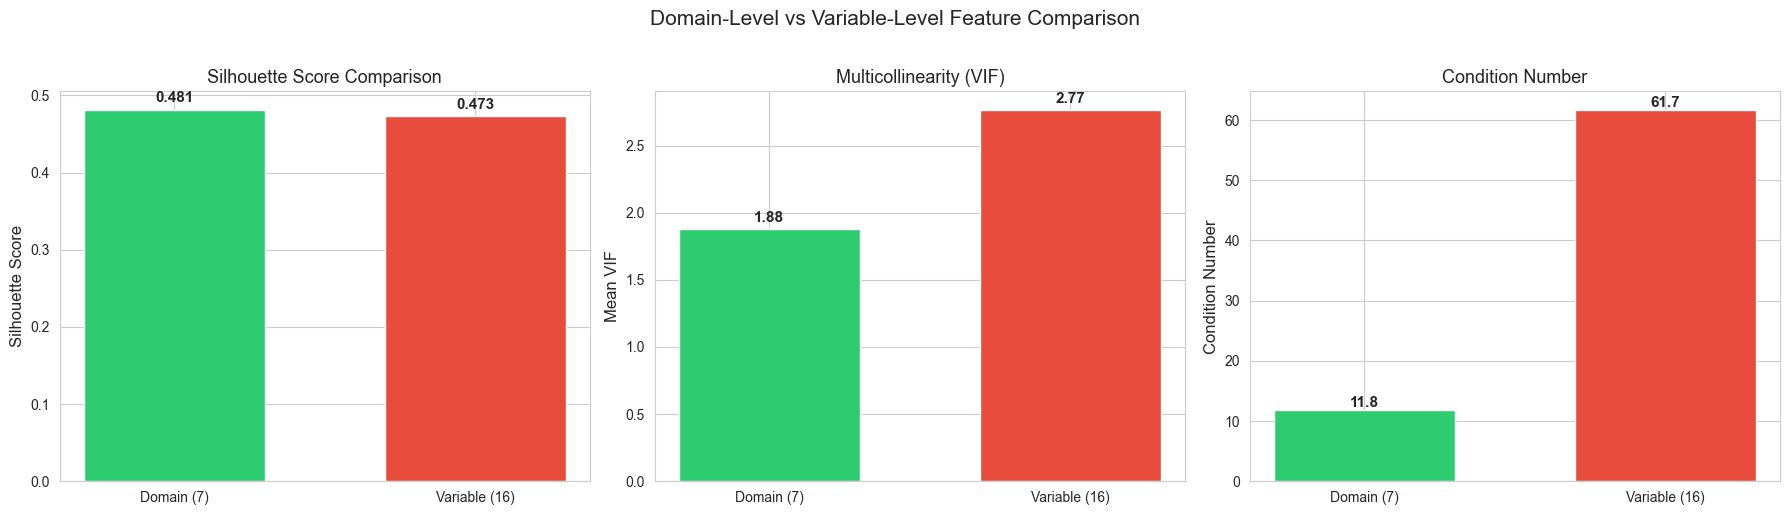

Saved: h4_domain_vs_variable.png


In [6]:
# Figure: Silhouette comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart: Silhouette
levels = ['Domain (7)', 'Variable (16)']
sils = [result_domain['silhouette'], result_variable['silhouette']]
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(levels, sils, color=colors, edgecolor='white', width=0.6)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score Comparison', fontsize=13)
for i, v in enumerate(sils):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

# Bar chart: Mean VIF
vifs = [vif_domain['VIF'].mean(), vif_var['VIF'].mean()]
axes[1].bar(levels, vifs, color=colors, edgecolor='white', width=0.6)
axes[1].set_ylabel('Mean VIF', fontsize=12)
axes[1].set_title('Multicollinearity (VIF)', fontsize=13)
for i, v in enumerate(vifs):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

# Bar chart: Condition number
conds = [cond_domain, cond_var]
axes[2].bar(levels, conds, color=colors, edgecolor='white', width=0.6)
axes[2].set_ylabel('Condition Number', fontsize=12)
axes[2].set_title('Condition Number', fontsize=13)
for i, v in enumerate(conds):
    axes[2].text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Domain-Level vs Variable-Level Feature Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h4_domain_vs_variable.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h4_domain_vs_variable.png')

In [7]:
# Score comparison table
comparison = pd.DataFrame([
    {'Metric': 'Silhouette Score', 'Domain-Level': result_domain['silhouette'],
     'Variable-Level': result_variable['silhouette'],
     'Winner': 'Domain' if result_domain['silhouette'] > result_variable['silhouette'] else 'Variable'},
    {'Metric': 'Mean VIF', 'Domain-Level': round(vif_domain['VIF'].mean(), 2),
     'Variable-Level': round(vif_var['VIF'].mean(), 2),
     'Winner': 'Domain' if vif_domain['VIF'].mean() < vif_var['VIF'].mean() else 'Variable'},
    {'Metric': 'Condition Number', 'Domain-Level': round(cond_domain, 1),
     'Variable-Level': round(cond_var, 1),
     'Winner': 'Domain' if cond_domain < cond_var else 'Variable'},
    {'Metric': 'Noise Fraction', 'Domain-Level': result_domain['noise_fraction'],
     'Variable-Level': result_variable['noise_fraction'],
     'Winner': 'Domain' if result_domain['noise_fraction'] < result_variable['noise_fraction'] else 'Variable'}
])

print('\n=== Metric Comparison ===')
print(comparison.to_string(index=False))

domain_wins = (comparison['Winner'] == 'Domain').sum()
print(f'\nDomain-level wins: {domain_wins}/4')
print(f'Threshold: ≥3 out of 4')


=== Metric Comparison ===
          Metric  Domain-Level  Variable-Level   Winner
Silhouette Score        0.4813          0.4731   Domain
        Mean VIF        1.8800          2.7700   Domain
Condition Number       11.8000         61.7000   Domain
  Noise Fraction        0.2909          0.0870 Variable

Domain-level wins: 3/4
Threshold: ≥3 out of 4


In [8]:
# H4 Verdict
h4_result = {
    'hypothesis': 'H4: Domain vs Variable Level',
    'verdict': 'SUPPORTED' if domain_wins >= 3 else 'NOT SUPPORTED',
    'domain_silhouette': result_domain['silhouette'],
    'variable_silhouette': result_variable['silhouette'],
    'domain_vif': round(vif_domain['VIF'].mean(), 2),
    'variable_vif': round(vif_var['VIF'].mean(), 2),
    'domain_condition': round(cond_domain, 1),
    'variable_condition': round(cond_var, 1),
    'domain_wins': domain_wins
}

print(f'\n{"="*50}')
print(f'H4 VERDICT: {h4_result["verdict"]}')
print(f'Domain silhouette: {h4_result["domain_silhouette"]} vs Variable: {h4_result["variable_silhouette"]}')
print(f'Domain VIF: {h4_result["domain_vif"]} vs Variable: {h4_result["variable_vif"]}')
print(f'Domain wins: {h4_result["domain_wins"]}/4')
print(f'{"="*50}')

with open(os.path.join(RESULTS_DIR, 'h4_results.pkl'), 'wb') as f:
    pickle.dump(h4_result, f, protocol=4)

print('\n=== Notebook 8 Complete ===')


H4 VERDICT: SUPPORTED
Domain silhouette: 0.4813 vs Variable: 0.4731
Domain VIF: 1.8799999952316284 vs Variable: 2.77
Domain wins: 3/4

=== Notebook 8 Complete ===
